In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv('results/results_adult_income.csv')
df2 = pd.read_csv('results/results_california_housing.csv')
df3 = pd.read_csv('results/results_porto_seguro.csv')

df = pd.concat([df1, df2, df3], ignore_index=True)
print(df.head(12))

             Model             Dataset            Task  Accuracy Mean  \
0           TabNet        Adult Income  Classification       0.848193   
1   FT-Transformer        Adult Income  Classification       0.849592   
2          XGBoost        Adult Income  Classification       0.875456   
3    Random Forest        Adult Income  Classification       0.863650   
4           TabNet  California Housing      Regression            NaN   
5   FT-Transformer  California Housing      Regression            NaN   
6          XGBoost  California Housing      Regression            NaN   
7    Random Forest  California Housing      Regression            NaN   
8           TabNet        Porto Seguro  Classification       0.963548   
9   FT-Transformer        Porto Seguro  Classification       0.963548   
10         XGBoost        Porto Seguro  Classification       0.963548   
11   Random Forest        Porto Seguro  Classification       0.963548   

    Accuracy Std  AUC-ROC Mean  AUC-ROC Std  Infer

In [3]:
# Define metric pairs (mean col, std col, output label)
metric_pairs = [
    ('Accuracy Mean',  'Accuracy Std',  'Accuracy CV%'),
    ('AUC-ROC Mean',   'AUC-ROC Std',   'AUC-ROC CV%'),
    ('RMSE Mean',      'RMSE Std',      'RMSE CV%'),
    ('MAE Mean',       'MAE Std',       'MAE CV%'),
]

for mean_col, std_col, cv_col in metric_pairs:
    if mean_col in df.columns and std_col in df.columns:
        df[cv_col] = (df[std_col] / df[mean_col]) * 100

# Display results
cv_cols = ['Model', 'Dataset', 'Task']
cv_cols += [cv_col for _, _, cv_col in metric_pairs if cv_col in df.columns]

result = df[cv_cols].copy().round(4)
print(result.to_string(index=False))

         Model            Dataset           Task  Accuracy CV%  AUC-ROC CV%  RMSE CV%  MAE CV%
        TabNet       Adult Income Classification        0.0690       0.3170       NaN      NaN
FT-Transformer       Adult Income Classification        0.1998       0.0703       NaN      NaN
       XGBoost       Adult Income Classification        0.0307       0.0193       NaN      NaN
 Random Forest       Adult Income Classification        0.0194       0.0308       NaN      NaN
        TabNet California Housing     Regression           NaN          NaN   10.3015  11.1116
FT-Transformer California Housing     Regression           NaN          NaN    2.7499   1.4817
       XGBoost California Housing     Regression           NaN          NaN    0.1662   0.2445
 Random Forest California Housing     Regression           NaN          NaN    0.2925   0.3868
        TabNet       Porto Seguro Classification        0.0000       1.7946       NaN      NaN
FT-Transformer       Porto Seguro Classification  

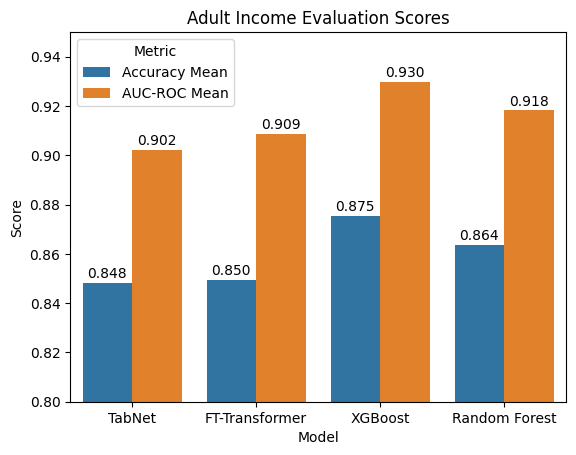

In [4]:
df1_long = df1.melt(
    id_vars=['Model'],
    value_vars=['Accuracy Mean', 'AUC-ROC Mean'],
    var_name='Metric',
    value_name='Score'
)

ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df1_long)
ax.set_title('Adult Income Evaluation Scores')
ax.set_ylim(0.80, 0.95)

for p in ax.patches:
    height = p.get_height()
    
    if height == 0:   # skip fake bars
        continue
        
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.002,
        f'{height:.3f}',
        ha='center'
    )
plt.show()

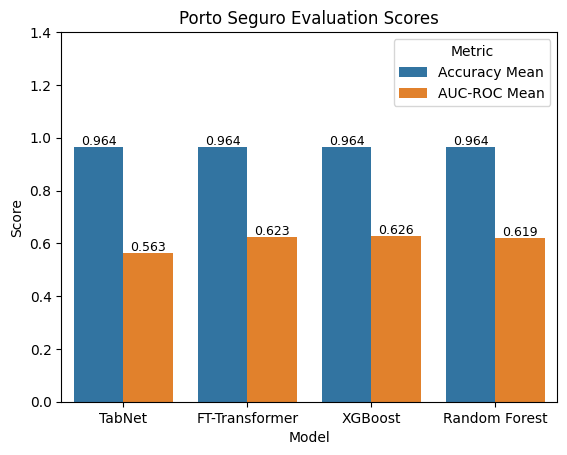

In [5]:
# --- Grouped barplot ---
df3_long = df3.melt(
    id_vars=['Model'],
    value_vars=['Accuracy Mean', 'AUC-ROC Mean'],
    var_name='Metric',
    value_name='Score'
)

ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df3_long)
ax.set_title('Porto Seguro Evaluation Scores')
ax.set_ylim(0.5, 1.09)
ax.set_ylim(0,1.4)

# Add annotations
for p in ax.patches:
    height = p.get_height()
    
    if height < 0.01:  # skip fake zero bars
        continue
        
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.01,
        f'{height:.3f}',
        ha='center',
        fontsize=9
    )

plt.show()


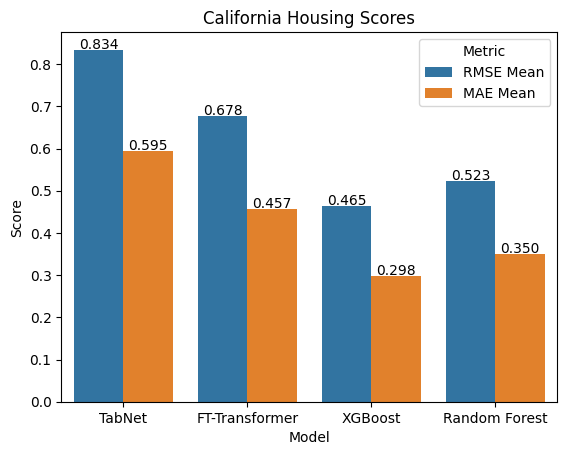

In [6]:
df2_long = df2.melt(
    id_vars=['Model'],
    value_vars=['RMSE Mean', 'MAE Mean'],
    var_name='Metric',
    value_name='Score'
)

ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df2_long)
ax.set_title('California Housing Scores')


for p in ax.patches:
    height = p.get_height()
    
    if height == 0:   
        continue
        
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.0025,
        f'{height:.3f}',
        ha='center'
    )

plt.show()

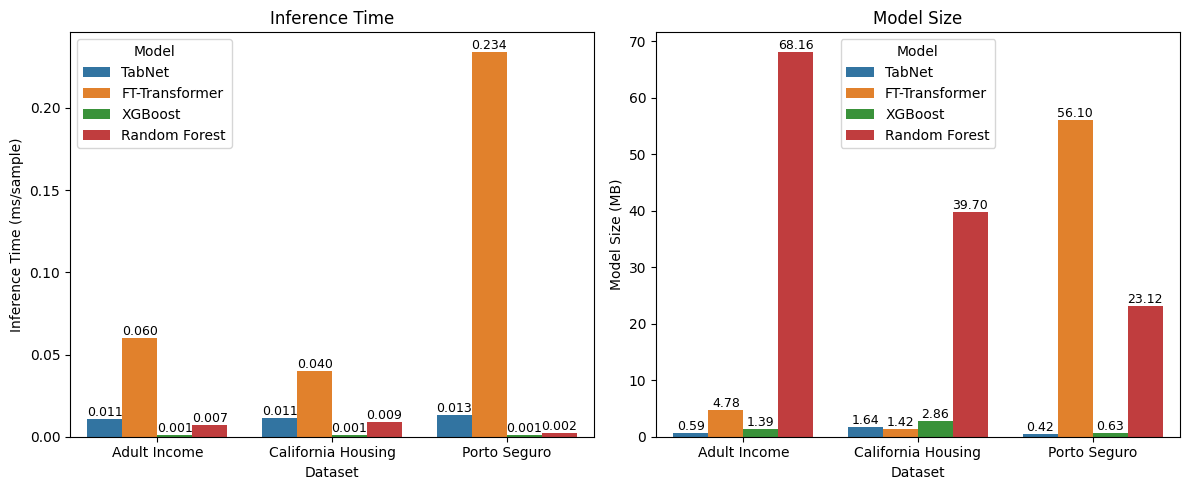

In [7]:
df['Model Size (MB)'] = df['Model Size (KB)'] / 1024
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Inference Time ---
sns.barplot(
    x='Dataset',
    y='Inference Time (ms/sample)',
    data=df,
    ax=axes[0],
    hue='Model',
)
axes[0].set_title('Inference Time')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=9)

# --- Right: Model Size ---
sns.barplot(
    x='Dataset',
    y='Model Size (MB)',
    data=df,
    ax=axes[1],
    hue='Model',
)
axes[1].set_title('Model Size')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
df2.head()

,Model,Dataset,Task,RMSE Mean,RMSE Std,MAE Mean,MAE Std,Inference Time (ms/sample),Model Size (KB),Feature Ranking (most to least important)
0,TabNet,California Housing,Regression,0.834352,0.085951,0.594673,0.066078,0.011277,1681.930664,"['Latitude', 'MedInc', 'Longitude', 'HouseAge'..."
1,FT-Transformer,California Housing,Regression,0.677785,0.018639,0.456942,0.006770,0.040160,1455.073242,"['MedInc', 'Latitude', 'Longitude', 'HouseAge'..."
2,XGBoost,California Housing,Regression,0.465024,0.000773,0.298444,0.000730,0.001333,2929.419922,"['MedInc', 'Longitude', 'AveOccup', 'Latitude'..."
3,Random Forest,California Housing,Regression,0.523306,0.001531,0.349797,0.001353,0.008856,40655.289062,"['MedInc', 'AveOccup', 'Latitude', 'Longitude'..."
